# 쇼핑몰 고객 군집화 실습 (Mall Customers Clustering)

- 목적  
  - 쇼핑몰 고객 데이터를 이용해 **소비 패턴에 따라 고객을 군집화**해 본다.
  - K-평균(K-Means), 계층적 군집화(Hierarchical Clustering), DBSCAN을 간단히 비교한다.

- 사용 데이터  
  - 파일 이름: `Mall_Customers.csv`  
  - 주요 변수  
    - `Gender`: 성별  
    - `Age`: 나이  
    - `Annual Income (k$)`: 연 소득(천 달러 단위)  
    - `Spending Score (1-100)`: 소비 점수(1~100, 점수가 높을수록 많이/자주 소비)


## 1. 라이브러리 불러오기


In [60]:
# 수치 계산 및 데이터 다루기
import numpy as np
import pandas as pd

# 시각화 도구
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리 및 군집화 관련 모듈
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

# 계층적 군집화에서 덴드로그램 그릴 때 사용할 함수
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# 그래프 스타일 설정 (개인 취향에 따라 조정 가능)
plt.style.use("default")
sns.set(font_scale=1.1)

# 경고 메시지 깔끔하게 숨기기
import warnings
warnings.filterwarnings("ignore")


## 2. 데이터 불러오기


In [61]:
# CSV 파일 읽어오기 (같은 폴더에 Mall_Customers.csv가 있다고 가정)
data_path = "../../Data/Mall_Customers.csv"
df = pd.read_csv(data_path)

# 앞부분 샘플 확인
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [62]:
# 기본 정보 확인
print("데이터 크기:", df.shape)
print("-" * 40)
df.info()


데이터 크기: (200, 5)
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [63]:
# 기초 통계량 확인
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [64]:
# 결측치 여부 확인
df.isna().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## 3. 간단한 EDA (탐색적 데이터 분석)

- ID 컬럼은 군집화에 사용하지 않으므로 제거한다.
- 성별 분포, 나이 분포, 연 소득 분포, 소비 점수 분포 등을 간단히 확인한다.


In [65]:
# CustomerID가 존재한다면 군집화에는 사용하지 않도록 따로 관리
if "CustomerID" in df.columns:
    df_id = df["CustomerID"]
    df = df.drop(columns=["CustomerID"])
else:
    df_id = None

df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


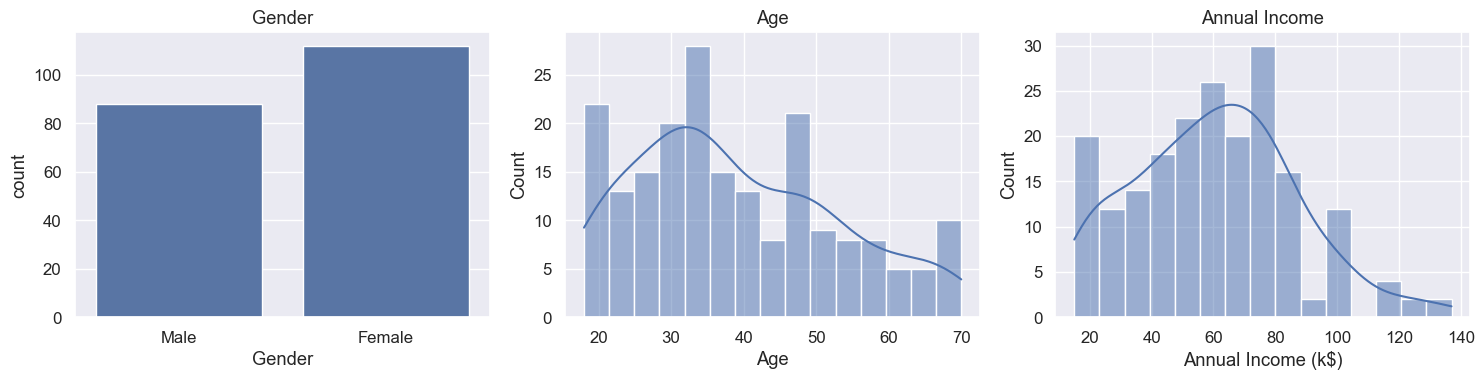

In [66]:
# 성별 분포 히스토그램 / 카운트플롯
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(data=df, x="Gender", ax=axes[0])
axes[0].set_title("Gender")

sns.histplot(data=df, x="Age", bins=15, ax=axes[1], kde=True)
axes[1].set_title("Age")

sns.histplot(data=df, x="Annual Income (k$)", bins=15, ax=axes[2], kde=True)
axes[2].set_title("Annual Income")

plt.tight_layout()
plt.show()


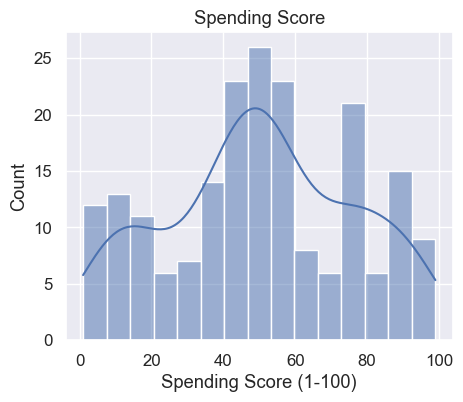

In [67]:
# 소비 점수 분포
plt.figure(figsize=(5, 4))
sns.histplot(data=df, x="Spending Score (1-100)", bins=15, kde=True)
plt.title("Spending Score")
plt.show()


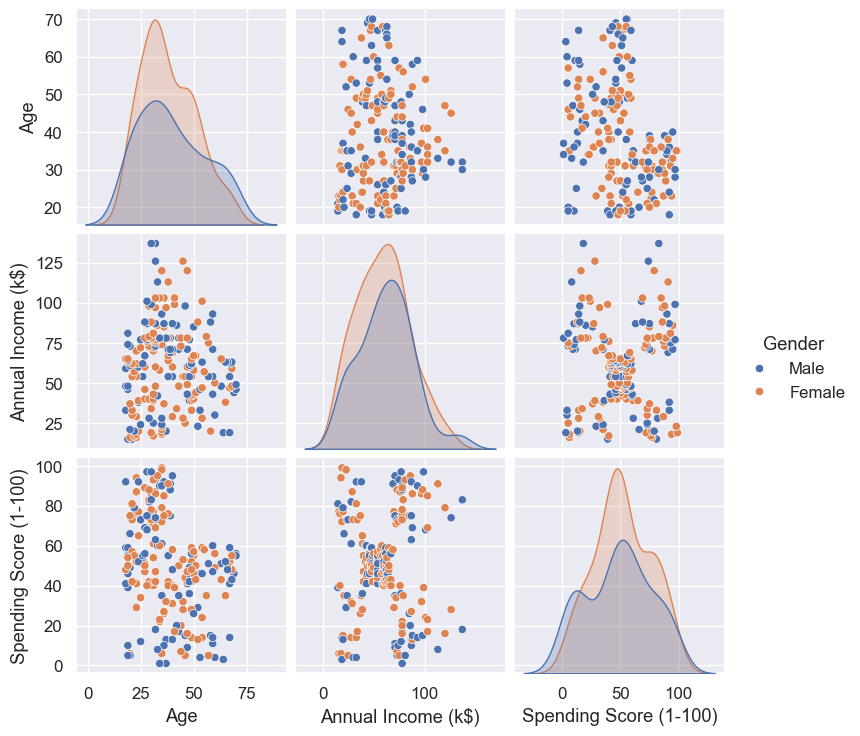

In [68]:
# Feature 간 관계 파악

sns.pairplot(df, hue = "Gender")
plt.show()

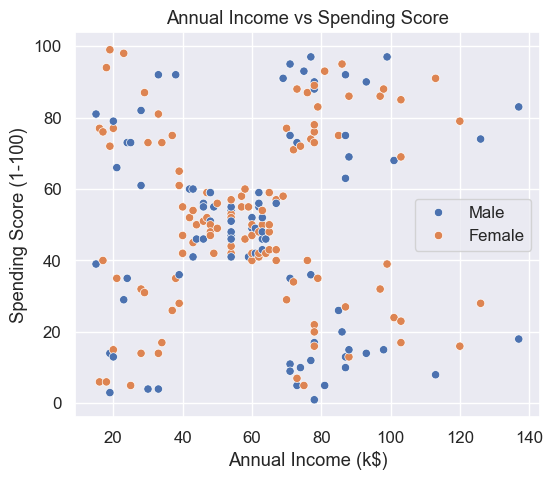

In [69]:
# 가장 눈에 띄는 두 피처 선택
# 연 소득 vs 소비 점수 산점도
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender"
)
plt.title("Annual Income vs Spending Score")
plt.legend()
plt.show()


- 위 산점도를 보면,  
  - `Annual Income (k$)`와 `Spending Score (1-100)`의 조합에서 **몇 개의 덩어리(클러스터)**가 눈으로도 어느 정도 보인다.  
  - 직관적으로 4개 또는 5개 정도의 구분이 가능해 보인다.

- 아래에서는 일단  
  - (1) 연 소득 vs 소비 점수 2차원만 사용한 군집화  
  - (2) Age까지 포함한 3차원 군집화  
  를 순서대로 진행해 본다.


## 4. K-평균(K-Means) 군집화

- K-Means는 **데이터를 K개의 그룹으로 나누는** 대표적인 군집화 알고리즘이다.
- 사용자가 **군집 개수 K를 미리 정해줘야** 한다.
- 군집 중심(centroid)을 반복적으로 갱신하면서, 각 샘플을 가장 가까운 중심에 배정한다.


In [70]:
# 4-1. 2차원 특징(연 소득, 소비 점수)만 사용
features_2d = df[["Annual Income (k$)", "Spending Score (1-100)"]].copy()

# 스케일링: 평균 0, 분산 1이 되도록 표준화
scaler_2d = StandardScaler()
X_2d = scaler_2d.fit_transform(features_2d)

X_2d[:5]


array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

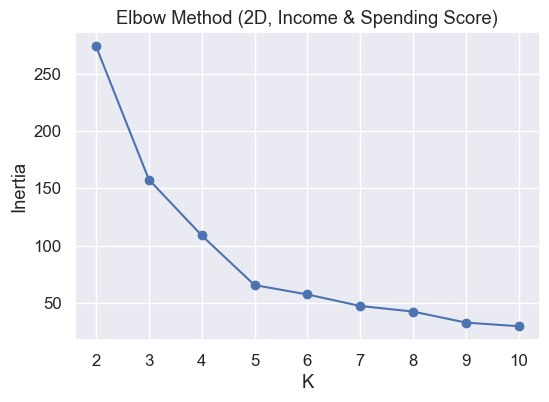

In [71]:
# 4-2. Elbow Method (관성값 inertia 기반)
ks = range(2, 11)
inertias = []

for k in ks:
    kmeans_k = KMeans(n_clusters=k, random_state=0, n_init="auto")
    kmeans_k.fit(X_2d)
    inertias.append(kmeans_k.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(ks, inertias, marker="o")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method (2D, Income & Spending Score)")
plt.xticks(ks)
plt.show()


In [72]:
# 4-3. Silhouette Score로 K 후보 비교
sil_scores = {}

for k in ks:
    kmeans_k = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_k = kmeans_k.fit_predict(X_2d)
    sil = silhouette_score(X_2d, labels_k)
    sil_scores[k] = sil

sil_scores


{2: 0.38665872527050493,
 3: 0.46658474419000145,
 4: 0.4939069237513199,
 5: 0.5546571631111091,
 6: 0.4567291383722191,
 7: 0.45399512817721743,
 8: 0.45647706631492346,
 9: 0.4591950348855181,
 10: 0.4591807027983601}

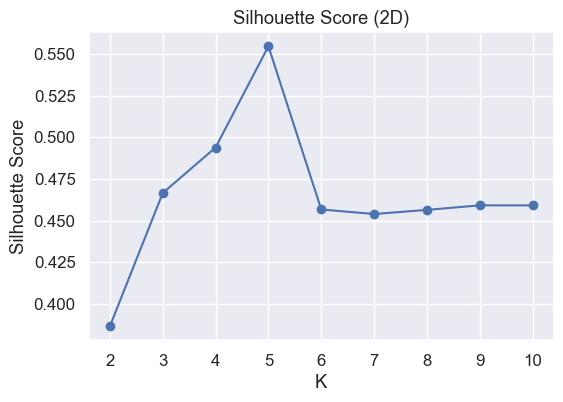

In [73]:
# Silhouette Score 시각화
plt.figure(figsize=(6, 4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score (2D)")
plt.xticks(list(sil_scores.keys()))
plt.show()


- Elbow Method와 Silhouette Score를 함께 보고,  
  - **너무 세분화되지 않으면서**,  
  - **군집 간 구분도는 적당히 확보되는** K 값을 선택한다.

- 예시로 `K = 5`를 한 번 사용해 보겠다.  
  (실습 시에는 K를 바꿔가며 직접 비교해 보는 것을 권장)


In [74]:
# 4-4. 최종 K-Means 모델 (예: K=5)
k_opt = 5

kmeans_final = KMeans(n_clusters=k_opt, random_state=0, n_init="auto")
labels_2d = kmeans_final.fit_predict(X_2d)

# 원본 데이터프레임에 군집 결과 추가
df_k2 = df.copy()
df_k2["KMeans_2D"] = labels_2d

df_k2.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_2D
0,Male,19,15,39,3
1,Male,21,15,81,4
2,Female,20,16,6,3
3,Female,23,16,77,4
4,Female,31,17,40,3


In [75]:
# 군집별 중심(원래 스케일로 복원)
centers_2d_scaled = kmeans_final.cluster_centers_
centers_2d = scaler_2d.inverse_transform(centers_2d_scaled)
centers_df = pd.DataFrame(centers_2d, columns=["Annual Income (k$)", "Spending Score (1-100)"])
centers_df["cluster"] = range(k_opt)
centers_df


,Annual Income (k$),Spending Score (1-100),cluster
0,55.296296,49.518519,0
1,86.538462,82.128205,1
2,88.200000,17.114286,2
3,26.304348,20.913043,3
4,25.727273,79.363636,4


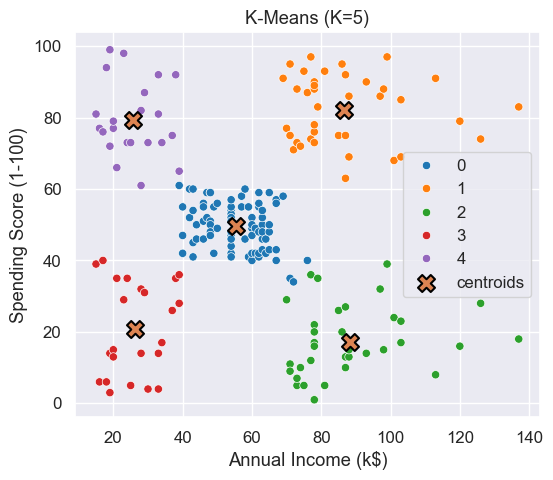

In [76]:
# 2차원 산점도에 군집 라벨 표시
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=df_k2["Annual Income (k$)"],
    y=df_k2["Spending Score (1-100)"],
    hue=df_k2["KMeans_2D"],
    palette="tab10"
)
plt.scatter(
    centers_df["Annual Income (k$)"],
    centers_df["Spending Score (1-100)"],
    s=150, marker="X", edgecolor="black", linewidth=1.5, label="centroids"
)
plt.title(f"K-Means (K={k_opt})")
plt.legend()
plt.show()


- 각 군집의 평균 특성을 보면, 다음과 같은 해석이 가능하다.  

예시)
- 군집 A: 연 소득 높고 / 소비 점수 높음 → **우수 VIP 고객**
- 군집 B: 연 소득 낮고 / 소비 점수 낮음 → **관심도가 낮은 고객**
- 군집 C: 연 소득은 낮지만 / 소비 점수는 높음 → **소득에 비해 소비 성향이 강한 고객**

실습에서는 `groupby`를 이용해 각 군집의 평균 Age, Income, Spending Score를 직접 계산해 보자.


In [77]:
# 군집별 평균 특성 확인
df_k2.groupby("KMeans_2D")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)


,Age,Annual Income (k$),Spending Score (1-100)
KMeans_2D,,,
0,42.7,55.3,49.5
1,32.7,86.5,82.1
2,41.1,88.2,17.1
3,45.2,26.3,20.9
4,25.3,25.7,79.4


## 5. 계층적 군집화 (Hierarchical Clustering)

- 계층적 군집화는 샘플들을 **계층 구조(트리 형태)**로 묶어 나가는 방식이다.
- 덴드로그램(dendrogram)을 그려 **군집이 어떻게 합쳐지는지** 시각적으로 볼 수 있다.
- 여기서는 연 소득 & 소비 점수를 사용하여 간단히 살펴본다.


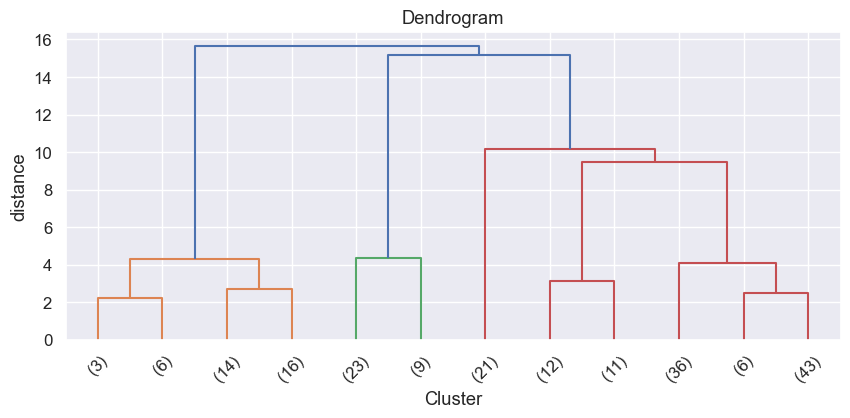

In [78]:
# 계층적 군집화를 위해 2D 특징 재사용 (스케일링된 X_2d 사용)
# linkage 함수에 들어가는 거리는 스케일이 영향을 주므로 스케일된 값 사용이 깔끔함
Z = linkage(X_2d, method="ward")  # ward: 군집 내 분산 최소화 기준

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode="lastp", p=12, leaf_rotation=45)
plt.title("Dendrogram")
plt.xlabel("Cluster")
plt.ylabel("distance")
plt.show()


In [79]:
# 덴드로그램을 보고, 예시로 5개 군집으로 자른다고 가정
n_clusters_hc = 5
hc_labels = fcluster(Z, n_clusters_hc, criterion="maxclust") - 1  # 0부터 시작하도록 -1

df_hc2 = df.copy()
df_hc2["HC_2D"] = hc_labels

df_hc2.groupby("HC_2D")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)


,Age,Annual Income (k$),Spending Score (1-100)
HC_2D,,,
0,32.7,86.5,82.1
1,41.0,89.4,15.6
2,25.3,25.1,80.0
3,45.2,26.3,20.9
4,42.5,55.8,49.1


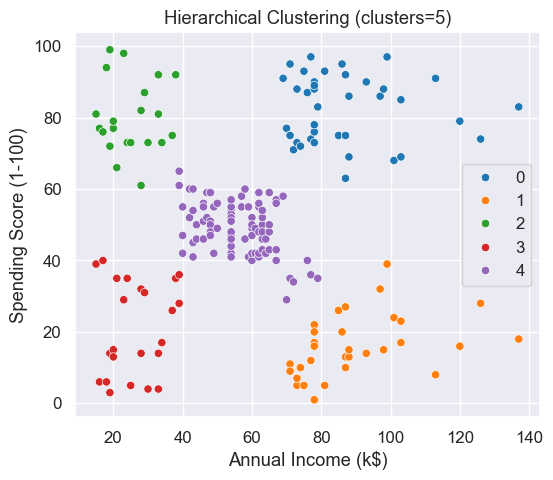

In [80]:
# 2차원 평면에 계층적 군집화 결과 시각화
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=df_hc2["Annual Income (k$)"],
    y=df_hc2["Spending Score (1-100)"],
    hue=df_hc2["HC_2D"],
    palette="tab10"
)
plt.title(f"Hierarchical Clustering (clusters={n_clusters_hc})")
plt.legend()
plt.show()


- K-Means 결과와 비교해 보면,
  - 어떤 군집은 K-Means와 비슷하게 나오지만,
  - 덴드로그램 컷 기준(어디서 자를지)에 따라 형태가 달라질 수 있다.

- 실제 프로젝트에서는  
  - 비즈니스 도메인,  
  - 해석 가능성,  
  - 실무에서 활용 용이성  
  등을 모두 고려해서 군집 개수와 알고리즘을 선택한다.


## 6. DBSCAN

- DBSCAN은 **밀도 기반(density-based)** 군집화 알고리즘이다.
- 장점
  - 군집 개수 K를 미리 지정할 필요가 없다.
  - 밀도가 낮은 영역에 있는 점들은 **노이즈(이상치)**로 처리 가능하다.
- 핵심 하이퍼파라미터
  - `eps`: 이웃으로 취급할 거리 기준
  - `min_samples`: 군집으로 인정하기 위한 최소 이웃 수


In [81]:
# 6-1. 스케일링된 2D 특징에 대해 DBSCAN 적용
eps_val = 0.5
min_samples_val = 5

dbscan_model = DBSCAN(eps=eps_val, min_samples=min_samples_val)
db_labels = dbscan_model.fit_predict(X_2d)

# -1은 노이즈(어느 군집에도 속하지 않는 점)
unique_labels = np.unique(db_labels)
unique_labels


array([-1,  0,  1])

In [82]:
# DBSCAN 결과를 원본 데이터프레임에 붙이기
df_db2 = df.copy()
df_db2["DBSCAN_2D"] = db_labels

df_db2["DBSCAN_2D"].value_counts().sort_index()


DBSCAN_2D
-1      8
 0    157
 1     35
Name: count, dtype: int64

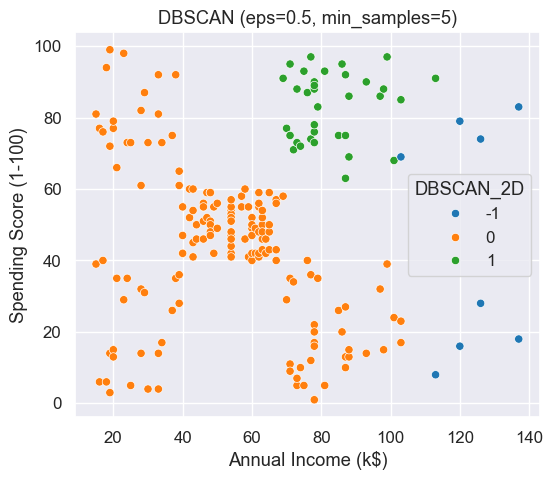

In [83]:
# 노이즈와 군집을 함께 시각화
plt.figure(figsize=(6, 5))
palette = "tab10"

sns.scatterplot(
    x=df_db2["Annual Income (k$)"],
    y=df_db2["Spending Score (1-100)"],
    hue=df_db2["DBSCAN_2D"],
    palette=palette,
    legend="full"
)
plt.title(f"DBSCAN (eps={eps_val}, min_samples={min_samples_val})")
plt.show()


In [84]:
# DBSCAN에서 노이즈를 제외한 경우 Silhouette Score를 간단히 확인
mask_core = df_db2["DBSCAN_2D"] != -1
labels_core = df_db2.loc[mask_core, "DBSCAN_2D"].values

if len(np.unique(labels_core)) > 1:
    sil_db = silhouette_score(X_2d[mask_core], labels_core)
    print("DBSCAN Silhouette Score (노이즈 제외):", sil_db)
else:
    print("실질적인 군집이 1개뿐이라 Silhouette Score를 계산하기 어렵습니다.")


DBSCAN Silhouette Score (노이즈 제외): 0.3875583892728279


### 6-2. 스케일링을 하지 않았을 때의 영향

- 거리 기반 알고리즘(K-Means, DBSCAN 등)은  
  - **축마다 단위와 분산이 다르면** 특정 변수에 과도하게 영향을 받을 수 있다.
- 이를 확인하기 위해, 스케일링을 하지 않은 상태에서 DBSCAN을 한 번 적용해 본다.


In [85]:
# 스케일링하지 않은 원본 2D 특징을 사용한 DBSCAN
raw_2d = features_2d.values

dbscan_raw = DBSCAN(eps=eps_val, min_samples=min_samples_val)
labels_raw = dbscan_raw.fit_predict(raw_2d)

df_db_raw = df.copy()
df_db_raw["DBSCAN_raw_2D"] = labels_raw

df_db_raw["DBSCAN_raw_2D"].value_counts().sort_index()


DBSCAN_raw_2D
-1    200
Name: count, dtype: int64

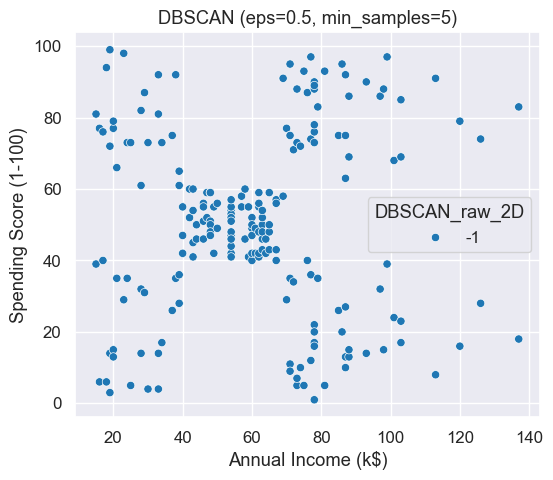

In [86]:
# 스케일링 X DBSCAN 결과 시각화
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=df_db_raw["Annual Income (k$)"],
    y=df_db_raw["Spending Score (1-100)"],
    hue=df_db_raw["DBSCAN_raw_2D"],
    palette="tab10"
)
plt.title(f"DBSCAN (eps={eps_val}, min_samples={min_samples_val})")
plt.show()


- 스케일링을 하지 않은 경우,
  - 특정 축(예: 연 소득)의 숫자 범위가 상대적으로 크다면
  - 거리 계산이 그 축 중심으로 이루어져 **군집 구분이 왜곡**될 수 있다.
- 그래서 실무에서도
  - 거리 기반 알고리즘을 쓸 때는 `StandardScaler`, `MinMaxScaler`와 같은
    **스케일링 전처리**를 거의 항상 고려한다.


## 7. 정리

- 이번 실습에서 다룬 내용
  1. 쇼핑몰 고객 데이터 구조 및 EDA
  2. K-Means 군집화 (Elbow Method, Silhouette Score를 이용한 K 선택)
  3. 계층적 군집화 및 덴드로그램
  4. DBSCAN을 통한 밀도 기반 군집화
  5. 스케일링 여부에 따른 결과 차이 비교

- 실제 분석에서는
  - 한 가지 알고리즘에만 의존하기보다  
  - 여러 알고리즘을 시도해 보고,  
  - **해석 가능성 + 비즈니스 목적**을 함께 고려해서 최종 군집 정의를 내린다.
